In [227]:
%pip install pandas
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [228]:
# Cell 1: imports and plotting setup

import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# If you're in Jupyter, this makes plots show inline
%matplotlib inline


In [229]:
# Cell 1b: configuration
# Set your default PID(s) of interest here.
# You can use a single int, or a list of ints.
import numpy as np
DEFAULT_PIDS = [np.int64(190835), np.int64(190836), np.int64(190837), np.int64(190838)]  # <- change this in ONE place to update examples


In [230]:
# Cell 2: path to your log file

log_path = Path("8cpu_mem_default.log")  # change if your file is elsewhere
assert log_path.exists(), f"Log file not found: {log_path}"


In [231]:
# Cell 3: parse PID -> cumulative energy from the log

TIME_RE = re.compile(r"Real time since poller start:\s*([0-9.]+)\s*s")
# Header now includes COMM: "PID      COMM             energy"
PID_CONSUMP_HEADER_RE = re.compile(r"PID\s+COMM\s+energy")
# Data rows now look like: "192808   mem_miss         19660700000"
PID_ROW_RE = re.compile(r"^\s*(\d+)\s+(\S+)\s+(\d+)\s*$")
CONSUMPTION_BLOCK_MARKER = "pid_to_consumption"  # appears in section header


def parse_pid_to_consumption(path: Path) -> pd.DataFrame:
    """
    Parse the log to extract per-PID cumulative energy over time.

    Expects blocks like:
        === PID → cumulative energy (pid_to_consumption) [comm="mem"] ===
        PID      COMM             energy
        192808   mem_miss         19660700000

    Returns a DataFrame with columns:
        - time_s: float (wall time since poller start, seconds)
        - pid: int
        - comm: str (process name from the log)
        - energy_j: float (Joules)

    Special case: if we encounter a pid_to_consumption block like:
        === PID → cumulative energy (pid_to_consumption) [comm="mem_miss"] ===
        PID      COMM             energy
    with no rows after the header, we treat it as a single value of 0
    and record a pseudo-PID 0 with energy_j = 0.0 at that time.
    """
    records = []

    current_time = None
    in_consumption_block = False
    seen_header_line = False
    had_pid_rows_in_block = False

    with path.open("r", encoding="utf-8", errors="replace") as f:
        for raw_line in f:
            line = raw_line.strip()

            # Skip ANSI clear-screen escape sequences (e.g. '\x1b[H\x1b[J')
            if line.startswith("\x1b"):
                continue

            # Update current time whenever we see it
            m_time = TIME_RE.search(line)
            if m_time:
                current_time = float(m_time.group(1))
                continue

            # Detect start of the PID -> cumulative energy block
            if CONSUMPTION_BLOCK_MARKER in line:
                in_consumption_block = True
                seen_header_line = False
                had_pid_rows_in_block = False
                continue

            if in_consumption_block:
                # First non-empty line after the marker should be the header "PID COMM energy"
                if not seen_header_line:
                    if PID_CONSUMP_HEADER_RE.search(line):
                        seen_header_line = True
                    # Either way, skip to next line
                    continue

                # End of block?
                if not line or line.startswith("===") or line.startswith("Polling"):
                    # No PID rows in this block -> treat as value of 0
                    if seen_header_line and not had_pid_rows_in_block and current_time is not None:
                        records.append(
                            {
                                "time_s": current_time,
                                "pid": 0,          # pseudo-PID representing "no entries" -> 0
                                "comm": "",       # no comm in this case
                                "energy_j": 0.0,
                            }
                        )
                    in_consumption_block = False
                    continue

                # Data rows: "PID  COMM  energy"
                m_row = PID_ROW_RE.match(line)
                if m_row and current_time is not None:
                    had_pid_rows_in_block = True
                    pid = int(m_row.group(1))
                    comm = m_row.group(2)
                    energy = float(m_row.group(3))  # Joules
                    records.append(
                        {
                            "time_s": current_time,
                            "pid": pid,
                            "comm": comm,
                            "energy_j": energy,
                        }
                    )

    df = pd.DataFrame.from_records(records)
    # Sort nicely
    if not df.empty:
        df = df.sort_values(["pid", "time_s"]).reset_index(drop=True)
    return df


df_pid = parse_pid_to_consumption(log_path)
print("Unique PIDs in log:", sorted(df_pid["pid"].unique()))
df_pid.head()


Unique PIDs in log: [np.int64(0), np.int64(195436), np.int64(195437), np.int64(195438), np.int64(195439), np.int64(195440), np.int64(195441), np.int64(195442), np.int64(195443), np.int64(195444), np.int64(195445), np.int64(195446), np.int64(195447), np.int64(195448), np.int64(195449), np.int64(195450), np.int64(195451), np.int64(195452), np.int64(195453), np.int64(195454), np.int64(195455), np.int64(195456), np.int64(195457), np.int64(195458), np.int64(195459), np.int64(195460), np.int64(195461), np.int64(195462), np.int64(195463), np.int64(195464), np.int64(195465), np.int64(195466), np.int64(195467), np.int64(195468), np.int64(195469), np.int64(195470), np.int64(195471), np.int64(195472), np.int64(195473), np.int64(195474), np.int64(195475), np.int64(195476), np.int64(195477), np.int64(195478), np.int64(195479), np.int64(195480), np.int64(195481), np.int64(195482), np.int64(195483)]


,time_s,pid,comm,energy_j
0,0.000019,0,,0.0
1,0.010879,0,,0.0
2,0.021692,0,,0.0
3,0.032492,0,,0.0
4,0.043289,0,,0.0


In [232]:
# Cell 4: check what we parsed

print(f"Total records: {len(df_pid)}")
print("PIDs found:", sorted(df_pid['pid'].unique()))
DEFAULT_PIDS = sorted(df_pid['pid'].unique())
DEFAULT_PIDS = [195436, 195437, 195438]
df_pid.tail()


Total records: 15489
PIDs found: [np.int64(0), np.int64(195436), np.int64(195437), np.int64(195438), np.int64(195439), np.int64(195440), np.int64(195441), np.int64(195442), np.int64(195443), np.int64(195444), np.int64(195445), np.int64(195446), np.int64(195447), np.int64(195448), np.int64(195449), np.int64(195450), np.int64(195451), np.int64(195452), np.int64(195453), np.int64(195454), np.int64(195455), np.int64(195456), np.int64(195457), np.int64(195458), np.int64(195459), np.int64(195460), np.int64(195461), np.int64(195462), np.int64(195463), np.int64(195464), np.int64(195465), np.int64(195466), np.int64(195467), np.int64(195468), np.int64(195469), np.int64(195470), np.int64(195471), np.int64(195472), np.int64(195473), np.int64(195474), np.int64(195475), np.int64(195476), np.int64(195477), np.int64(195478), np.int64(195479), np.int64(195480), np.int64(195481), np.int64(195482), np.int64(195483)]


,time_s,pid,comm,energy_j
15484,9.846868,195483,mem_miss,9.257511e+10
15485,9.858712,195483,mem_miss,9.275364e+10
15486,9.870569,195483,mem_miss,9.293279e+10
15487,9.882399,195483,mem_miss,9.308874e+10
15488,9.894206,195483,mem_miss,9.326620e+10


In [233]:
# Cell 5: compute power (dE/dt) per PID

df_pid = df_pid.copy()

# Sort just to be safe
df_pid = df_pid.sort_values(["pid", "time_s"]).reset_index(drop=True)

# Compute diffs within each PID
df_pid["dE"] = df_pid.groupby("pid")["energy_j"].diff()
df_pid["dt"] = df_pid.groupby("pid")["time_s"].diff()

# Power in Watts (J/s)
df_pid["power_w"] = df_pid["dE"] / df_pid["dt"]

df_pid.head(10)


,time_s,pid,comm,energy_j,dE,dt,power_w
0,0.000019,0,,0.0,NaN,NaN,NaN
1,0.010879,0,,0.0,0.0,0.010860,0.0
2,0.021692,0,,0.0,0.0,0.010813,0.0
3,0.032492,0,,0.0,0.0,0.010800,0.0
4,0.043289,0,,0.0,0.0,0.010797,0.0
5,0.054076,0,,0.0,0.0,0.010787,0.0
6,0.064859,0,,0.0,0.0,0.010783,0.0
7,0.075639,0,,0.0,0.0,0.010780,0.0
8,0.086421,0,,0.0,0.0,0.010782,0.0
9,0.097211,0,,0.0,0.0,0.010790,0.0


In [234]:
# Cell 6: helper to filter logs by PID set

def get_pid_logs(df: pd.DataFrame, pids):
    """
    Return a DataFrame subset for the given PID or list of PIDs.
    """
    if isinstance(pids, (int, str)):
        pids = [int(pids)]
    else:
        pids = [int(p) for p in pids]

    sub = df[df["pid"].isin(pids)].copy()
    return sub.sort_values(["pid", "time_s"])


# Example: logs only for the configured DEFAULT_PIDS
df_selected = get_pid_logs(df_pid, DEFAULT_PIDS)
df_selected.head()


,time_s,pid,comm,energy_j,dE,dt,power_w
1114,3.345663,195436,mem_miss,1.008150e+09,NaN,NaN,NaN
1115,3.358165,195436,mem_miss,1.100920e+09,92770000.0,0.012502,7.420413e+09
1116,3.370622,195436,mem_miss,1.139830e+09,38910000.0,0.012457,3.123545e+09
1117,3.383041,195436,mem_miss,1.225890e+09,86060000.0,0.012419,6.929704e+09
1118,3.395507,195436,mem_miss,1.312860e+09,86970000.0,0.012466,6.976576e+09


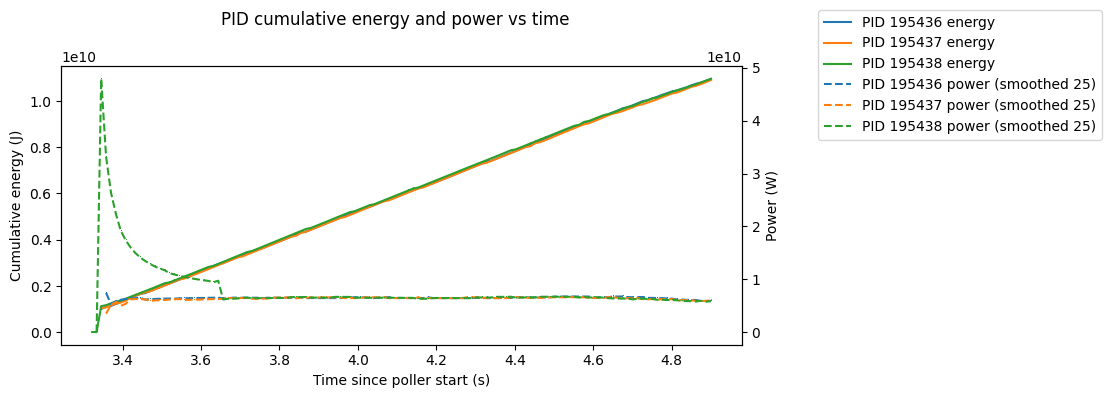

In [235]:
# Cell 7: plotting function for chosen PIDs (with rolling average smoothing)

def plot_pids(df: pd.DataFrame, pids, show_power=True, rolling_window=None):
    """
    Plot energy vs time for the given PIDs.
    Optionally plot power vs time on a second axis.

    Args:
        df: DataFrame with columns [time_s, pid, energy_j, power_w]
        pids: int or list of ints
        show_power: bool, whether to add power curves.
        rolling_window: int or None
            If set, applies a rolling mean to power_w to smooth noise.
    """
    sub = get_pid_logs(df, pids)
    if sub.empty:
        print("No data for requested PIDs:", pids)
        return

    if isinstance(pids, (int, str)):
        pids = [int(pids)]
    else:
        pids = [int(p) for p in pids]

    # One figure: energy & power (with twin y-axis)
    fig, ax1 = plt.subplots(figsize=(8, 4))

    # ENERGY
    for pid in pids:
        df_p = sub[sub["pid"] == pid]
        ax1.plot(
            df_p["time_s"],
            df_p["energy_j"],
            marker=",",
            label=f"PID {pid} energy",
        )

    ax1.set_xlabel("Time since poller start (s)")
    ax1.set_ylabel("Cumulative energy (J)")
    ax1.tick_params(axis="y")

    lines = []
    labels = []

    for line in ax1.get_lines():
        lines.append(line)
        labels.append(line.get_label())

    # POWER (optional)
    if show_power:
        ax2 = ax1.twinx()

        for pid in pids:
            df_p = sub[sub["pid"] == pid].dropna(subset=["power_w"])

            # Apply rolling average smoothing if enabled
            if rolling_window and rolling_window > 1:
                df_p = df_p.copy()
                df_p["power_w_smooth"] = (
                    df_p["power_w"].rolling(window=rolling_window, min_periods=1).mean()
                )
                power_series = df_p["power_w_smooth"]
                label = f"PID {pid} power (smoothed {rolling_window})"
            else:
                power_series = df_p["power_w"]
                label = f"PID {pid} power"

            ax2.plot(
                df_p["time_s"],
                power_series,
                linestyle="--",
                marker=",",
                label=label,
            )

        ax2.set_ylabel("Power (W)")
        ax2.tick_params(axis="y")

        for line in ax2.get_lines():
            lines.append(line)
            labels.append(line.get_label())

    fig.legend(lines, labels, loc="upper left", bbox_to_anchor=(1.02, 1.0))
    fig.suptitle("PID cumulative energy and power vs time")
    fig.tight_layout()
    plt.show()
plot_pids(df_pid, DEFAULT_PIDS, rolling_window=25)
